<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/05_ai_systems/computer_vision/experiment_medical_image_classification_cnn_mnist_and_malaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN Application in Medical Imaging**

# Convolutional Neural Networks (CNNs) are widely used in medical imaging for:


*   disease detection
*   tumor classification
*   organ segmentation
*   anomaly detection
*   X-ray analysis
*   MRI/CT scan interpretation

# Applications:

*   Pneumonia detection
*   Brain tumor classification
*   Skin cancer detection
*   Breast cancer screening
*   Diabetic retinopathy detection

# Using:

*   TensorFlow
*   Keras
*   Transfer Learning
*   Medical image preprocessing


# Mathematical Foundation
## Convolution
$$\text{FeatureMap} = X * K$$
CNN learns disease-relevant filters.

## ReLU Activation
$$f(x) = \max(0, x)$$

## Max Pooling
$$P(i, j) = \max(X_{\text{window}})$$

## Binary Cross Entropy
For disease classification:
$$L = -[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print(X_train.shape)

print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


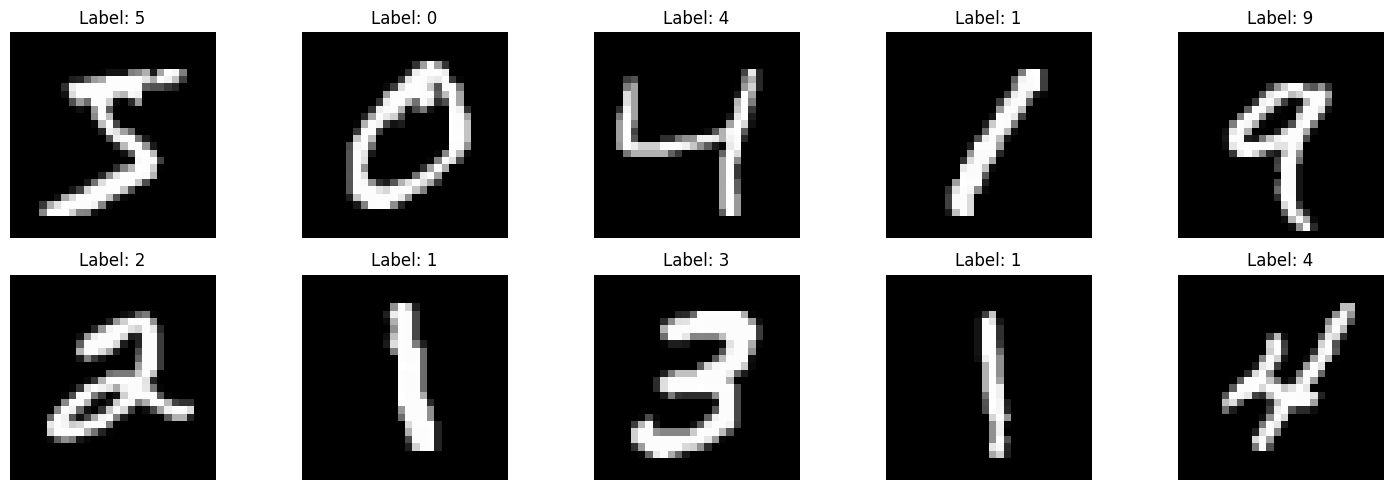

In [ ]:
# Visualize Top 10 MNIST Images

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(f"Label: {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

Normalize Images

In [ ]:
X_train = X_train / 255.0

X_test = X_test / 255.0

Reshape for CNN

CNN expects:

(height, width, channels)

In [ ]:
X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

One-Hot Encoding

In [ ]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

Build CNN

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.5))

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train CNN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9107 - loss: 0.2889 - val_accuracy: 0.9806 - val_loss: 0.0636
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9720 - loss: 0.0943 - val_accuracy: 0.9851 - val_loss: 0.0489
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.9786 - loss: 0.0733 - val_accuracy: 0.9883 - val_loss: 0.0409
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9829 - loss: 0.0573 - val_accuracy: 0.9880 - val_loss: 0.0401
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9851 - loss: 0.0476 - val_accuracy: 0.9879 - val_loss: 0.0438


Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9906 - loss: 0.0285
Test Accuracy: 0.9905999898910522


Predict Image

In [ ]:
prediction = model.predict(X_test[:1])

print(
    "Predicted Class:",
    np.argmax(prediction)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Class: 7


Show Image

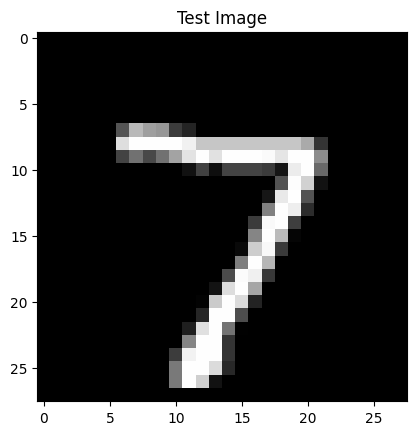

In [ ]:
plt.imshow(
    X_test[0].reshape(28, 28),
    cmap="gray"
)

plt.title("Test Image")

plt.show()

for malaria dataset


In [ ]:
import tensorflow_datasets as tfds

import tensorflow as tf

import matplotlib.pyplot as plt

Load Malaria Dataset

In [ ]:
dataset, info = tfds.load(

    "malaria",

    with_info=True,

    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.2LBFRN_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [ ]:
print(info)

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

Split Dataset

In [ ]:
train_data = dataset["train"]

Visualize Medical Images

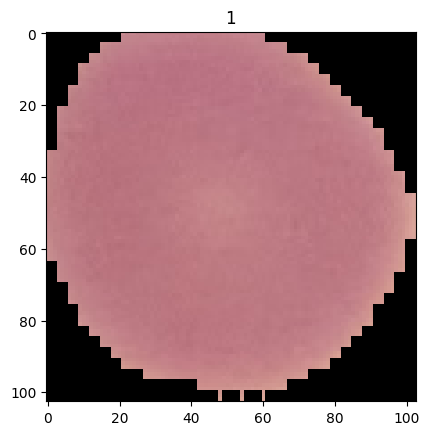

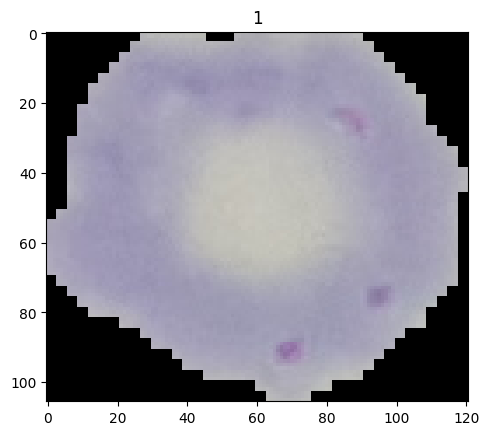

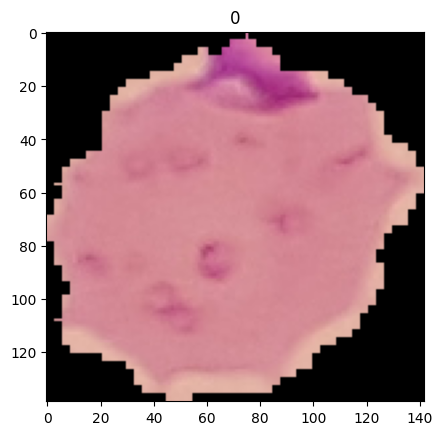

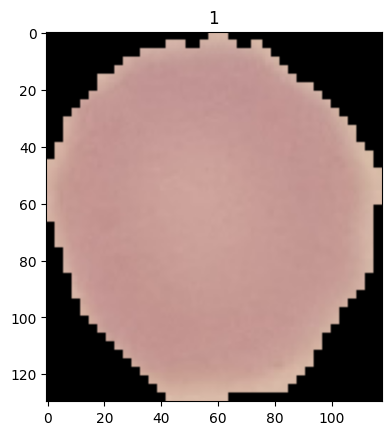

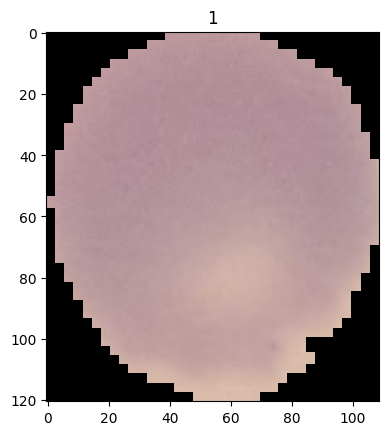

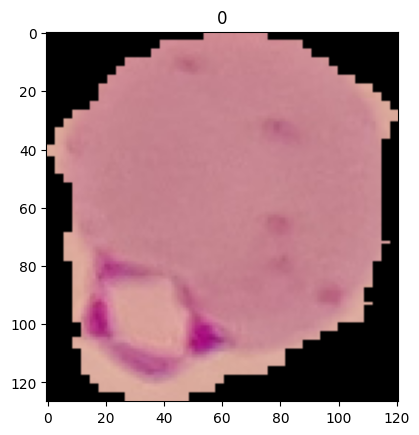

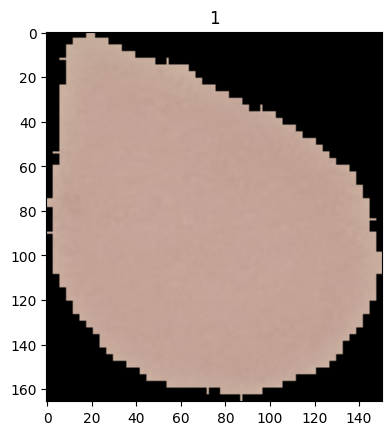

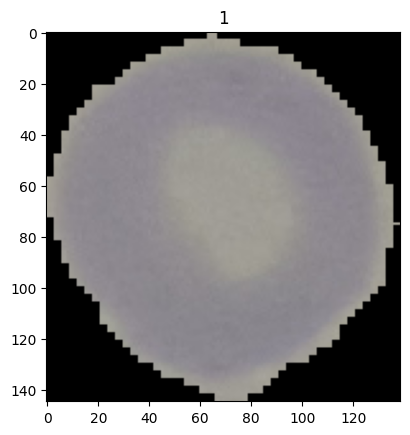

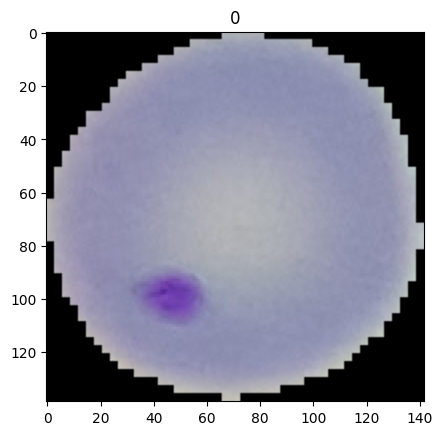

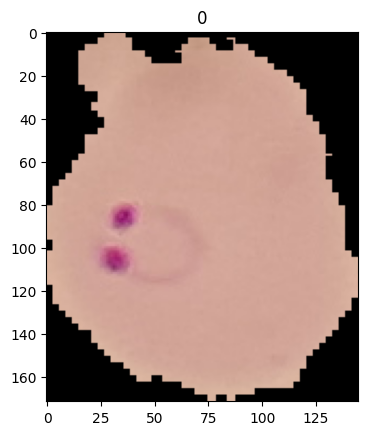

In [ ]:
for image, label in train_data.take(10):

    plt.imshow(image)

    plt.title(label.numpy())

    plt.show()

Resize + Normalize Images

In [ ]:
IMG_SIZE = 128

def preprocess(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image / 255.0

    return image, label

Apply Preprocessing

In [ ]:
train_data = train_data.map(preprocess)

Shuffle + Batch

In [ ]:
train_data = train_data.shuffle(1000)

train_data = train_data.batch(32)

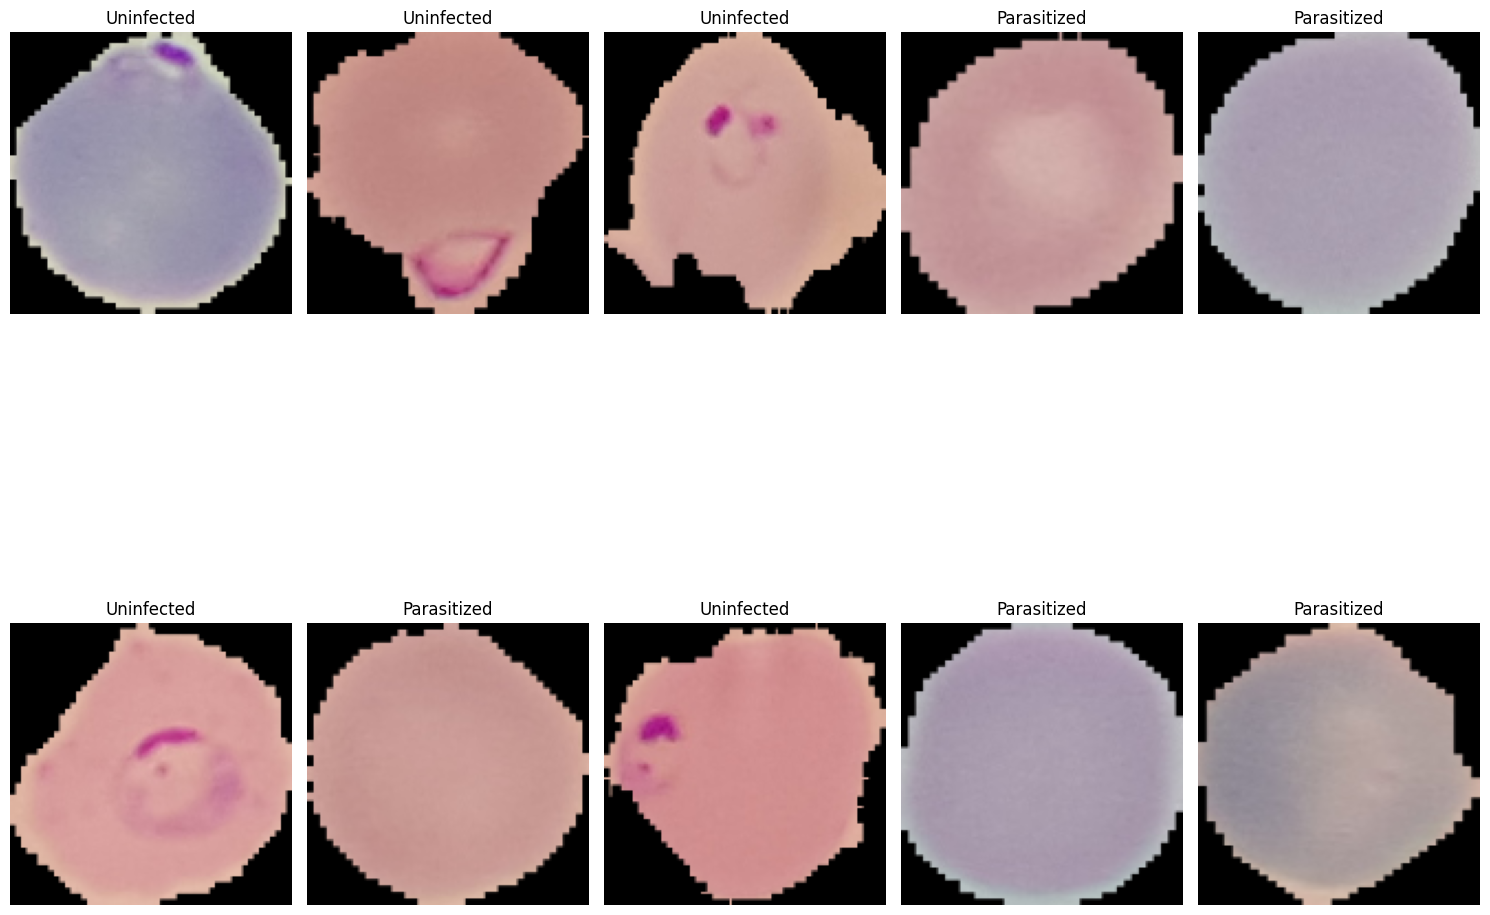

In [ ]:
# Visualize Batched & Preprocessed Images

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for images, labels in train_data.take(1):

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        plt.imshow(images[i])

        plt.title(
            "Parasitized" if labels[i].numpy() == 1 else "Uninfected"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

Build Medical CNN

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential()

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.5))

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile CNN

In [ ]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

Train CNN

In [ ]:
history = model.fit(
    train_data,
    epochs=5
)

Epoch 1/5
862/862 ━━━━━━━━━━━━━━━━━━━━ 603s 695ms/step - accuracy: 0.8848 - loss: 0.2964
Epoch 2/5
862/862 ━━━━━━━━━━━━━━━━━━━━ 592s 687ms/step - accuracy: 0.9499 - loss: 0.1532
Epoch 3/5
862/862 ━━━━━━━━━━━━━━━━━━━━ 612s 709ms/step - accuracy: 0.9575 - loss: 0.1330
Epoch 4/5
862/862 ━━━━━━━━━━━━━━━━━━━━ 591s 685ms/step - accuracy: 0.9600 - loss: 0.1205
Epoch 5/5
862/862 ━━━━━━━━━━━━━━━━━━━━ 579s 671ms/step - accuracy: 0.9629 - loss: 0.1102


Save Model

In [ ]:
model.save(
    "malaria_medical_cnn.keras"
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.BI44CZ_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman

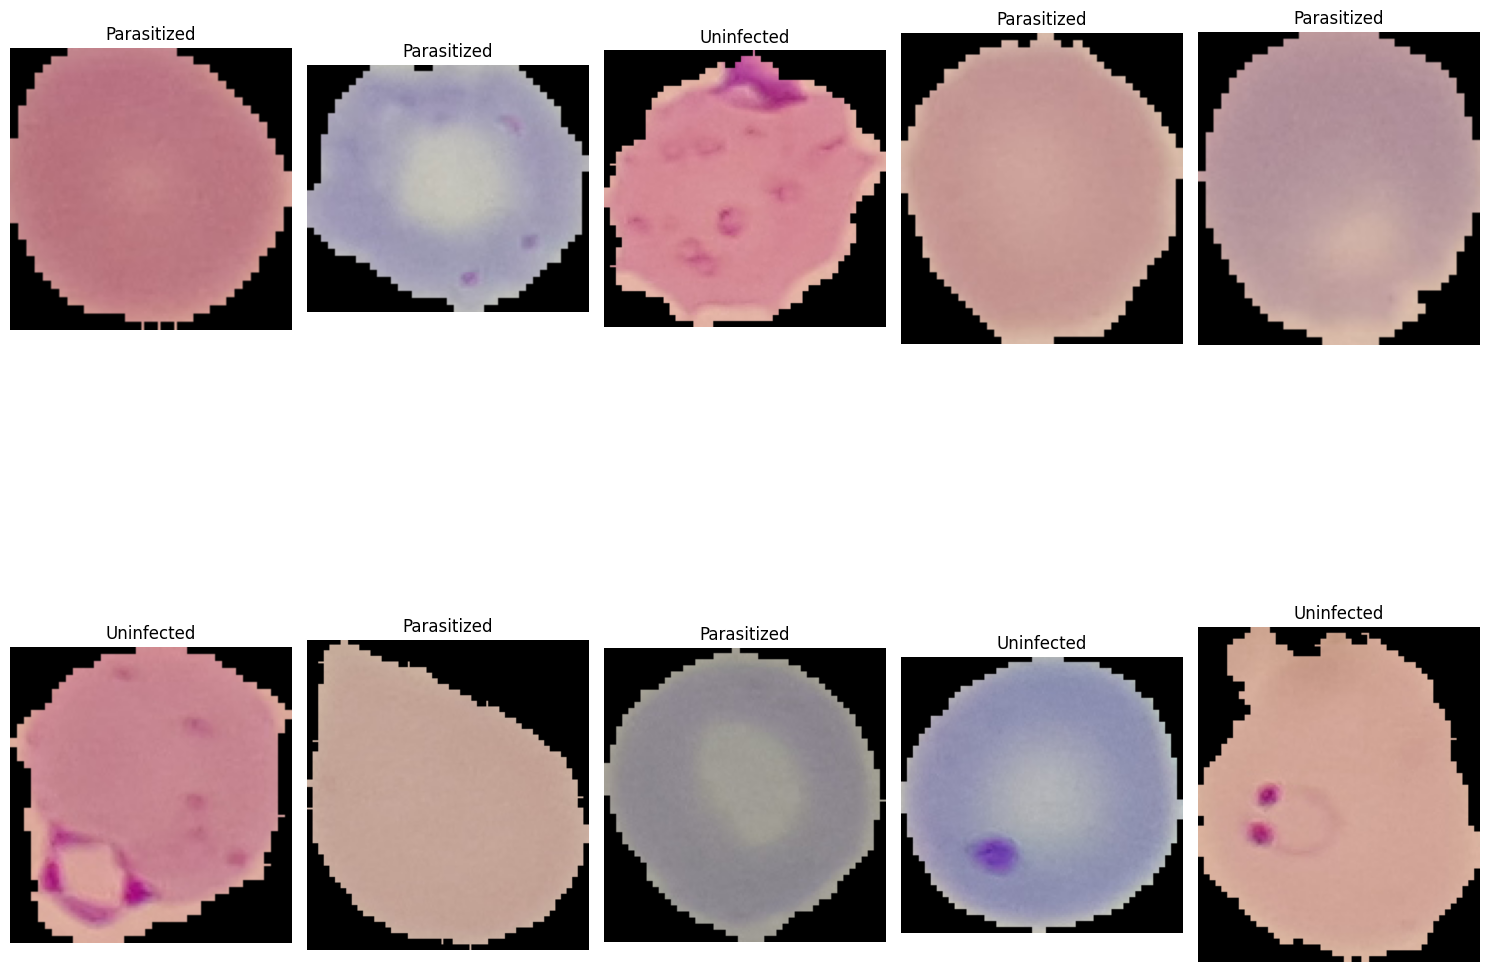

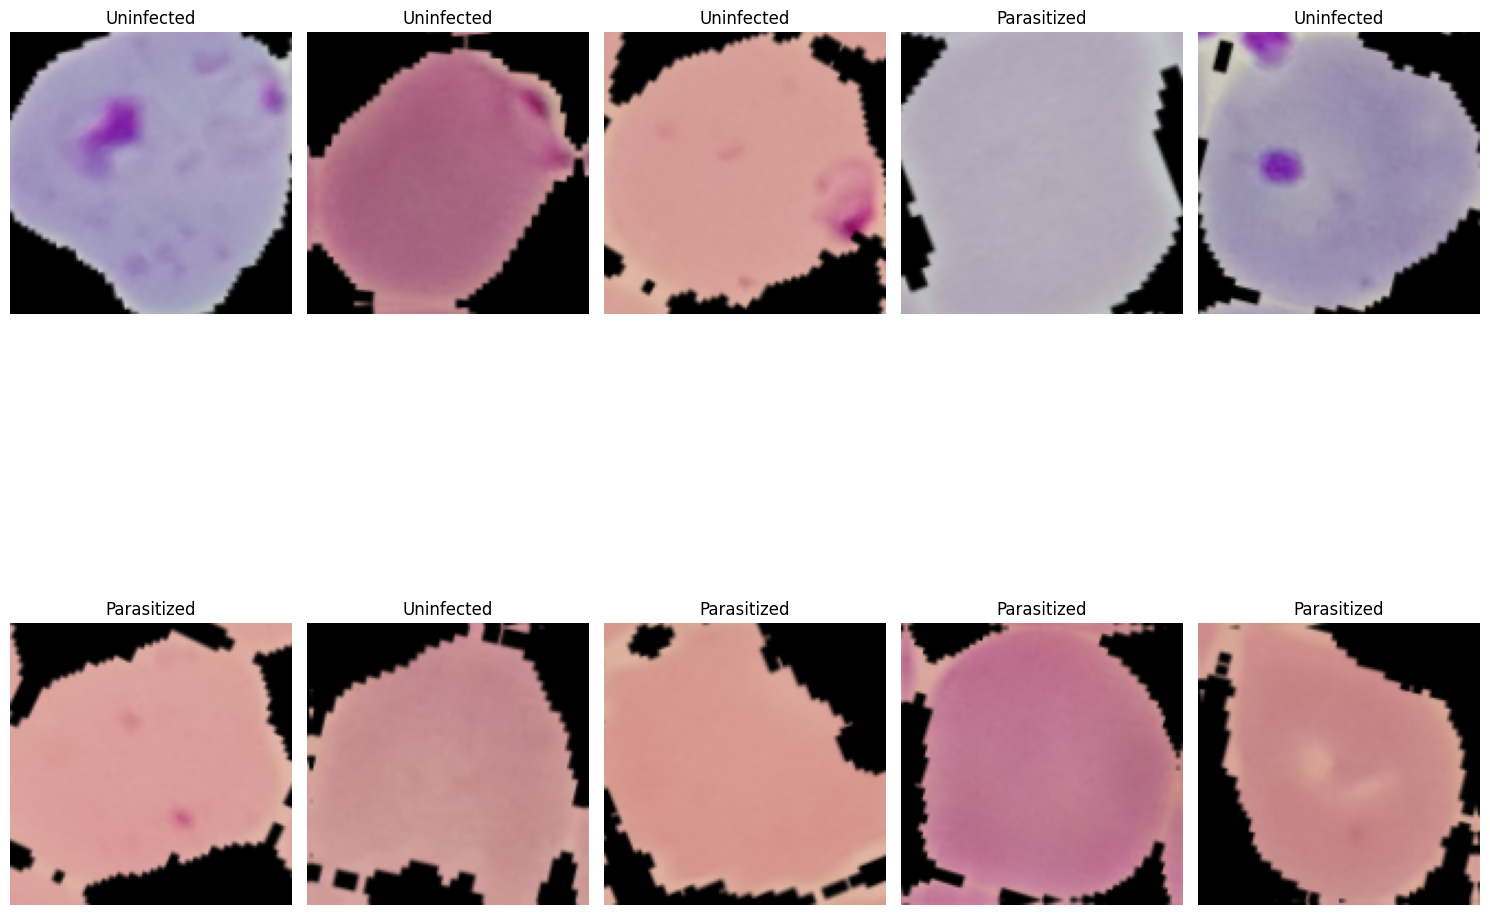

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 198s 310ms/step - accuracy: 0.8021 - loss: 0.4177 - val_accuracy: 0.8984 - val_loss: 0.2574
Epoch 2/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 146s 226ms/step - accuracy: 0.9382 - loss: 0.1882 - val_accuracy: 0.9512 - val_loss: 0.1680
Epoch 3/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 146s 231ms/step - accuracy: 0.9470 - loss: 0.1676 - val_accuracy: 0.9497 - val_loss: 0.1558
Epoch 4/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.9516 - loss: 0.1551 - val_accuracy: 0.9541 - val_loss: 0.1445
Epoch 5/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 145s 234ms/step - accuracy: 0.9549 - loss: 0.1437 - val_accuracy: 0.9586 - val_loss: 0.1431
Epoch 6/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 145s 233ms/step - accuracy: 0.9559 - loss: 0.1389 - val_accuracy: 0.9554 - val_loss: 0.1357
Epoch 7/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 144s 231ms/step - accuracy: 0.9558 - loss: 0.1360 - val_accuracy: 0.9592 - val_loss: 0.1250
Epoch 8/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 200s 229ms/step - accuracy: 0.9572 -

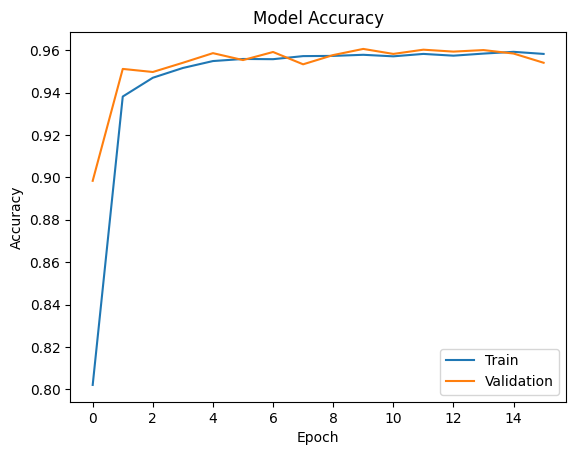

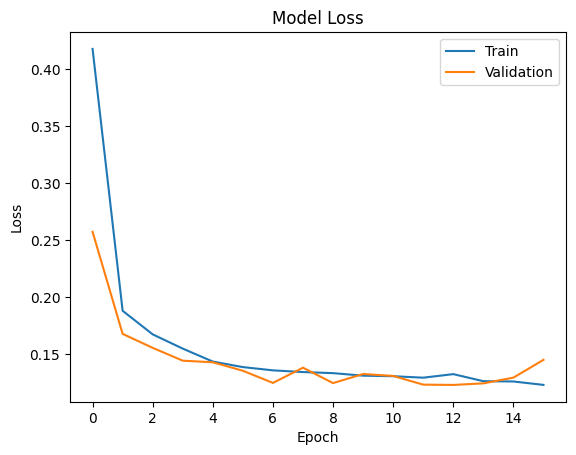

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━

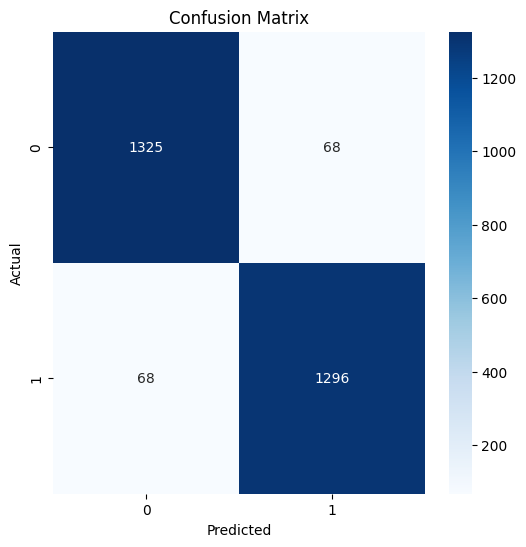


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1393
           1       0.95      0.95      0.95      1364

    accuracy                           0.95      2757
   macro avg       0.95      0.95      0.95      2757
weighted avg       0.95      0.95      0.95      2757


Model Saved Successfully!


In [ ]:
# ============================================================
# COMPLETE ADVANCED MALARIA CNN PIPELINE
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

# ============================================================
# LOAD DATASET
# ============================================================

dataset, info = tfds.load(
    "malaria",
    with_info=True,
    as_supervised=True
)

dataset = dataset["train"]

print(info)

# ============================================================
# VISUALIZE RAW IMAGES
# ============================================================

plt.figure(figsize=(15, 15))

for i, (image, label) in enumerate(dataset.take(10)):

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        "Parasitized"
        if label.numpy() == 1
        else "Uninfected"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# DATASET SPLIT
# ============================================================

DATASET_SIZE = 27558

train_size = int(0.7 * DATASET_SIZE)
val_size = int(0.2 * DATASET_SIZE)
test_size = int(0.1 * DATASET_SIZE)

train_data = dataset.take(train_size)

remaining = dataset.skip(train_size)

val_data = remaining.take(val_size)

test_data = remaining.skip(val_size)

# ============================================================
# DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

# ============================================================
# PREPROCESSING
# ============================================================

IMG_SIZE = 128

def preprocess(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image / 255.0

    image = data_augmentation(image)

    return image, label

# ============================================================
# APPLY PREPROCESSING
# ============================================================

train_data = train_data.map(preprocess)

val_data = val_data.map(preprocess)

test_data = test_data.map(preprocess)

# ============================================================
# SHUFFLE + BATCH + PREFETCH
# ============================================================

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.shuffle(1000)

train_data = train_data.batch(BATCH_SIZE)

train_data = train_data.prefetch(AUTOTUNE)

val_data = val_data.batch(BATCH_SIZE)

val_data = val_data.prefetch(AUTOTUNE)

test_data = test_data.batch(BATCH_SIZE)

test_data = test_data.prefetch(AUTOTUNE)

# ============================================================
# VISUALIZE PREPROCESSED + BATCHED IMAGES
# ============================================================

plt.figure(figsize=(15, 15))

for images, labels in train_data.take(1):

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        plt.imshow(images[i])

        plt.title(
            "Parasitized"
            if labels[i].numpy() == 1
            else "Uninfected"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# BUILD CNN MODEL
# ============================================================

model = Sequential()

model.add(
    Input(shape=(128, 128, 3))
)

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.5))

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

model.summary()

# ============================================================
# CALLBACKS
# ============================================================

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

checkpoint = ModelCheckpoint(

    "best_malaria_model.keras",

    save_best_only=True
)

# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=20,

    callbacks=[
        early_stop,
        checkpoint
    ]
)

# ============================================================
# EVALUATE MODEL
# ============================================================

loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy:", accuracy)

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

# ============================================================
# LOSS GRAPH
# ============================================================

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

# ============================================================
# PREDICTIONS
# ============================================================

y_true = []

y_pred = []

for images, labels in test_data:

    predictions = model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions.flatten())

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# ============================================================
# SAVE FINAL MODEL
# ============================================================

model.save(
    "malaria_medical_cnn_final.keras"
)

print("\nModel Saved Successfully!")